# Task 1: Analysis of Symptom Co-Occurrence Patterns using Apriori Algorithm

## TODO
- [ ] compare across different min_support values
- [ ] unslop analysis portion

## 1.1 Setup and Imports

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from apriori_miner import AprioriMiner

## 1.2 Helper Functions

In [2]:
def clean_disease_data(df):
    """
    Basic cleaning: whitespace, empty strings, basic formatting.
    """
    df = df.copy()
    # Remove whitespace
    string_cols = df.select_dtypes(include="object").columns
    for col in string_cols:
        df[col] = df[col].str.strip() if df[col].dtype == "object" else df[col]

    # Replace empty strings with NaN
    df = df.replace("", np.nan)

    # Lowercase and replace spaces with underscores
    symptom_cols = [col for col in df.columns if "Symptom" in col]
    for col in symptom_cols:
        df[col] = df[col].str.lower().str.replace(" _", "_").str.replace("_ ", "_")

    return df


def normalize_symptoms(df, normalization_dict):
    """
    Normalize symptoms using a mapping dictionary.
    """
    df = df.copy()

    symptom_cols = [col for col in df.columns if "Symptom" in col]

    for col in symptom_cols:
        df[col] = df[col].map(
            lambda x: normalization_dict.get(x, x) if pd.notna(x) else x
        )

    return df


def merge_disease_symptoms(df):
    """
    Merge multiple rows per disease into single rows with all symptoms.
    """
    symptom_cols = [col for col in df.columns if "Symptom" in col]

    # Collect all unique symptoms per disease
    disease_symptoms = {}
    for _, row in df.iterrows():
        disease = row["Disease"]
        symptoms = [s for s in row[symptom_cols] if pd.notna(s)]

        if disease not in disease_symptoms:
            disease_symptoms[disease] = set()
        disease_symptoms[disease].update(symptoms)

    # Create merged dataframe
    merged_data = []
    for disease, symptoms in disease_symptoms.items():
        symptoms_list = sorted(list(symptoms))
        row_dict = {"Disease": disease}

        for i, symptom in enumerate(symptoms_list, 1):
            row_dict[f"Symptom_{i}"] = symptom

        merged_data.append(row_dict)

    df_merged = pd.DataFrame(merged_data)

    # Ensure all Symptom columns exist
    for i in range(1, len(df_merged.columns)):
        if f"Symptom_{i}" not in df_merged.columns:
            df_merged[f"Symptom_{i}"] = np.nan

    # Reorder columns
    cols = ["Disease"] + [f"Symptom_{i}" for i in range(1, len(df_merged.columns))]
    df_merged = df_merged[cols]

    return df_merged


def preprocess_disease_data(df, norm_dict):
    """Clean -> normalize -> merge"""
    df = clean_disease_data(df)
    df = normalize_symptoms(df, norm_dict)
    df = merge_disease_symptoms(df)
    return df


def convert_to_transactions(df):
    """
    Convert disease-symptom dataframe to transaction format for Apriori.

    Each disease becomes a transaction (basket) containing its symptoms (items).
    """
    transactions = []
    symptom_cols = [col for col in df.columns if "Symptom" in col]

    for _, row in df.iterrows():
        # Collect non-null symptoms for this disease
        symptoms = [row[col] for col in symptom_cols if pd.notna(row[col])]

        # Only add if there are symptoms
        if symptoms:
            transactions.append(frozenset(symptoms))

    return transactions

## 1.3 Exploratory Data Analysis

In [ ]:
df_raw = pd.read_csv("../data/raw/itachi9604_disease-symptom-description-dataset.csv")
print(f"Raw data shape: {df_raw.shape}")
display(df_raw.head())

Raw data shape: (4920, 18)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print(df_raw["Disease"].value_counts())

Disease
Fungal infection                           120
Hepatitis C                                120
Hepatitis E                                120
Alcoholic hepatitis                        120
Tuberculosis                               120
Common Cold                                120
Pneumonia                                  120
Dimorphic hemmorhoids(piles)               120
Heart attack                               120
Varicose veins                             120
Hypothyroidism                             120
Hyperthyroidism                            120
Hypoglycemia                               120
Osteoarthristis                            120
Arthritis                                  120
(vertigo) Paroymsal  Positional Vertigo    120
Acne                                       120
Urinary tract infection                    120
Psoriasis                                  120
Hepatitis D                                120
Hepatitis B                                120
Aller

## 1.4 Data Preprocessing

In [5]:
SYMPTOM_NORMALIZATION = {
    # Spacing/formatting fixes
    "dischromic _patches": "dischromic_patches",
    "spotting_ urination": "spotting_urination",
    "foul_smell_of urine": "foul_smell_of_urine",
    # Typo fixes
    "cold_hands_and_feets": "cold_hands_and_feet",
    "scurring": "scarring",
    "swollen_extremeties": "swollen_extremities",
    # Pain location normalization
    "stomach_pain": "abdominal_pain",
    "belly_pain": "abdominal_pain",
}

In [6]:
df_final = preprocess_disease_data(df_raw, SYMPTOM_NORMALIZATION)
display(df_final)

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,dischromic_patches,itching,nodal_skin_eruptions,skin_rash,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Allergy,chills,continuous_sneezing,shivering,watering_from_eyes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GERD,abdominal_pain,acidity,chest_pain,cough,ulcers_on_tongue,vomiting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Chronic cholestasis,abdominal_pain,itching,loss_of_appetite,nausea,vomiting,yellowing_of_eyes,yellowish_skin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Drug Reaction,abdominal_pain,burning_micturition,itching,skin_rash,spotting_urination,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Peptic ulcer diseae,abdominal_pain,indigestion,internal_itching,loss_of_appetite,passage_of_gases,vomiting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,AIDS,extra_marital_contacts,high_fever,muscle_wasting,patches_in_throat,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Diabetes,blurred_and_distorted_vision,excessive_hunger,fatigue,increased_appetite,irregular_sugar_level,lethargy,obesity,polyuria,restlessness,weight_loss,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Gastroenteritis,dehydration,diarrhoea,sunken_eyes,vomiting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Bronchial Asthma,breathlessness,cough,family_history,fatigue,high_fever,mucoid_sputum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.5 Apriori Algorithm

In [7]:
transactions = convert_to_transactions(df_final)

Testing different min_support values...

Fitting Apriori with min_support=0.05 (count=3)
Total transactions: 41
Generating 1-itemsets...
  Found 31 frequent 1-itemsets
Generating 2-itemsets...
  Found 104 frequent 2-itemsets
Generating 3-itemsets...
  Found 153 frequent 3-itemsets
Generating 4-itemsets...
  Found 143 frequent 4-itemsets
Generating 5-itemsets...
  Found 86 frequent 5-itemsets
Generating 6-itemsets...
  Found 36 frequent 6-itemsets
Generating 7-itemsets...
  Found 9 frequent 7-itemsets
Generating 8-itemsets...
  Found 1 frequent 8-itemsets
Total frequent itemsets: 563

min_support = 0.05 (≥2 diseases)
  Frequent itemsets: 563
  Association rules: 7741
  High-quality rules (conf≥0.7, lift≥1.5): 5668
  Avg confidence: 0.827
  Avg lift: 7.683
--------------------------------------------------------------------------------
Fitting Apriori with min_support=0.1 (count=5)
Total transactions: 41
Generating 1-itemsets...
  Found 19 frequent 1-itemsets
Generating 2-itemsets...
  F

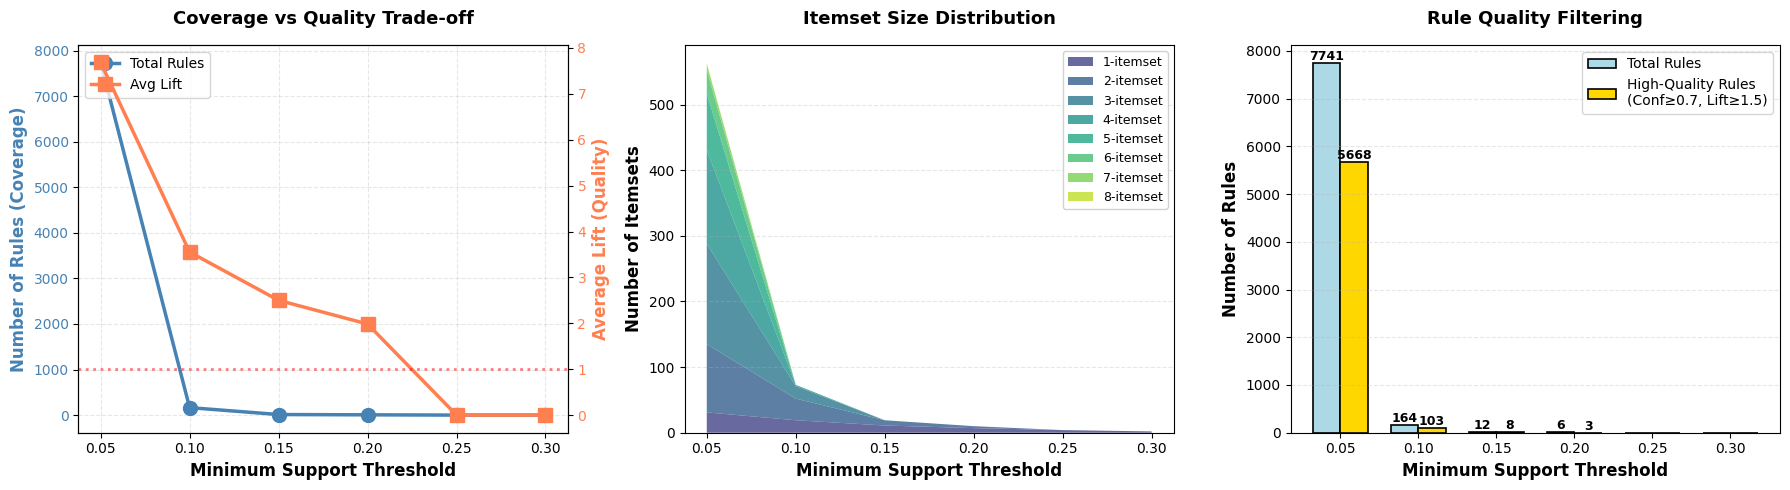


RECOMMENDATION

✓ RECOMMENDED min_support: 0.05
  → Produces 5668 high-quality rules
  → Balances coverage (7741 total rules)
  → Average lift: 7.68

📊 Interpretation:
  • Lower support (0.05-0.10): Captures rare symptom combinations (may be noisy)
  • Medium support (0.15-0.20): Balanced - common enough to be reliable
  • Higher support (0.25-0.30): Only very frequent patterns (may miss insights)

💡 For your report:
  1. Use the recommended support value for main analysis
  2. Show the trade-off graph (Plot 1) to justify your choice
  3. Discuss how support threshold affects pattern discovery


In [ ]:
import pandas as pd

# Define range of min_support values to test
support_values = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

# Store metrics for comparison
results = []

print("Testing different min_support values...\n")
print("=" * 80)

for min_sup in support_values:
    # Fit Apriori with current min_support
    temp_miner = AprioriMiner(min_support=min_sup)
    temp_miner.fit(transactions)
    temp_miner.generate_rules(min_confidence=0.5)

    # Collect metrics
    total_itemsets = len(temp_miner.all_frequent_itemsets)
    total_rules = len(temp_miner.association_rules)

    # Itemset size distribution
    size_dist = {}
    for k in temp_miner.frequent_itemsets.keys():
        size_dist[k] = len(temp_miner.frequent_itemsets[k])

    # Rule quality metrics
    if total_rules > 0:
        rules_df_temp = pd.DataFrame(temp_miner.association_rules)
        avg_confidence = rules_df_temp["confidence"].mean()
        avg_lift = rules_df_temp["lift"].mean()
        max_lift = rules_df_temp["lift"].max()
        high_quality_rules = len(
            rules_df_temp[
                (rules_df_temp["confidence"] >= 0.7) & (rules_df_temp["lift"] >= 1.5)
            ]
        )
    else:
        avg_confidence = avg_lift = max_lift = high_quality_rules = 0

    # Store results
    results.append(
        {
            "min_support": min_sup,
            "min_support_count": int(min_sup * len(transactions)),
            "total_itemsets": total_itemsets,
            "total_rules": total_rules,
            "size_distribution": size_dist,
            "avg_confidence": avg_confidence,
            "avg_lift": avg_lift,
            "max_lift": max_lift,
            "high_quality_rules": high_quality_rules,
        }
    )

    # Print summary
    print(f"\nmin_support = {min_sup} (≥{int(min_sup * len(transactions))} diseases)")
    print(f"  Frequent itemsets: {total_itemsets}")
    print(f"  Association rules: {total_rules}")
    print(f"  High-quality rules (conf≥0.7, lift≥1.5): {high_quality_rules}")
    if total_rules > 0:
        print(f"  Avg confidence: {avg_confidence:.3f}")
        print(f"  Avg lift: {avg_lift:.3f}")
    print("-" * 80)

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("COMPARISON SUMMARY")
print("=" * 80)
print(
    comparison_df[
        [
            "min_support",
            "min_support_count",
            "total_itemsets",
            "total_rules",
            "avg_confidence",
            "avg_lift",
        ]
    ].to_string(index=False)
)

# ============================================================================
# IMPROVED VISUALIZATION: 3 Focused Plots
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: Trade-off between Coverage and Selectivity ---
ax1 = axes[0]
ax1_twin = ax1.twinx()

# Primary axis: Number of patterns (coverage)
line1 = ax1.plot(
    comparison_df["min_support"],
    comparison_df["total_rules"],
    "o-",
    linewidth=2.5,
    markersize=10,
    label="Total Rules",
    color="steelblue",
)
ax1.set_xlabel("Minimum Support Threshold", fontsize=12, fontweight="bold")
ax1.set_ylabel(
    "Number of Rules (Coverage)", fontsize=12, color="steelblue", fontweight="bold"
)
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.grid(alpha=0.3, linestyle="--")

# Secondary axis: Average lift (quality)
line2 = ax1_twin.plot(
    comparison_df["min_support"],
    comparison_df["avg_lift"],
    "s-",
    linewidth=2.5,
    markersize=10,
    label="Avg Lift",
    color="coral",
)
ax1_twin.set_ylabel(
    "Average Lift (Quality)", fontsize=12, color="coral", fontweight="bold"
)
ax1_twin.tick_params(axis="y", labelcolor="coral")
ax1_twin.axhline(
    y=1.0, color="red", linestyle=":", linewidth=2, alpha=0.5, label="Baseline (Lift=1)"
)

ax1.set_title("Coverage vs Quality Trade-off", fontsize=13, fontweight="bold", pad=15)

# Combined legend
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left", fontsize=10)

# --- PLOT 2: Itemset Size Distribution (Stacked Area) ---
ax2 = axes[1]

# Prepare data for stacked area plot
max_size = max(
    max(r["size_distribution"].keys()) for r in results if r["size_distribution"]
)
support_labels = [f"{r['min_support']:.2f}" for r in results]

# Create matrix for stacking
size_matrix = np.zeros((len(results), max_size))
for i, result in enumerate(results):
    for size, count in result["size_distribution"].items():
        size_matrix[i, size - 1] = count

# Stacked area plot
colors = plt.cm.viridis(np.linspace(0.2, 0.9, max_size))
ax2.stackplot(
    range(len(results)),
    size_matrix.T,
    labels=[f"{i + 1}-itemset" for i in range(max_size)],
    colors=colors,
    alpha=0.8,
)

ax2.set_xlabel("Minimum Support Threshold", fontsize=12, fontweight="bold")
ax2.set_ylabel("Number of Itemsets", fontsize=12, fontweight="bold")
ax2.set_title("Itemset Size Distribution", fontsize=13, fontweight="bold", pad=15)
ax2.set_xticks(range(len(results)))
ax2.set_xticklabels(support_labels)
ax2.legend(loc="upper right", fontsize=9, framealpha=0.9)
ax2.grid(axis="y", alpha=0.3, linestyle="--")

# --- PLOT 3: High-Quality Rules Filter ---
ax3 = axes[2]

x_pos = np.arange(len(comparison_df))
width = 0.35

bars1 = ax3.bar(
    x_pos - width / 2,
    comparison_df["total_rules"],
    width,
    label="Total Rules",
    color="lightblue",
    edgecolor="black",
    linewidth=1.2,
)
bars2 = ax3.bar(
    x_pos + width / 2,
    comparison_df["high_quality_rules"],
    width,
    label="High-Quality Rules\n(Conf≥0.7, Lift≥1.5)",
    color="gold",
    edgecolor="black",
    linewidth=1.2,
)

ax3.set_xlabel("Minimum Support Threshold", fontsize=12, fontweight="bold")
ax3.set_ylabel("Number of Rules", fontsize=12, fontweight="bold")
ax3.set_title("Rule Quality Filtering", fontsize=13, fontweight="bold", pad=15)
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f"{s:.2f}" for s in comparison_df["min_support"]])
ax3.legend(fontsize=10)
ax3.grid(axis="y", alpha=0.3, linestyle="--")

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax3.text(
                bar.get_x() + bar.get_width() / 2.0,
                height,
                f"{int(height)}",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )

plt.tight_layout()
# plt.savefig('task1_support_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# RECOMMENDATION WITH JUSTIFICATION
# ============================================================================
print("\n" + "=" * 80)
print("RECOMMENDATION")
print("=" * 80)

# Find optimal support value
optimal_idx = comparison_df["high_quality_rules"].idxmax()
optimal_support = comparison_df.loc[optimal_idx, "min_support"]
optimal_rules = comparison_df.loc[optimal_idx, "high_quality_rules"]

print(f"\n✓ RECOMMENDED min_support: {optimal_support}")
print(f"  → Produces {optimal_rules} high-quality rules")
print(
    f"  → Balances coverage ({comparison_df.loc[optimal_idx, 'total_rules']} total rules)"
)
print(f"  → Average lift: {comparison_df.loc[optimal_idx, 'avg_lift']:.2f}")

print("\n📊 Interpretation:")
print(
    "  • Lower support (0.05-0.10): Captures rare symptom combinations (may be noisy)"
)
print("  • Medium support (0.15-0.20): Balanced - common enough to be reliable")
print("  • Higher support (0.25-0.30): Only very frequent patterns (may miss insights)")

print("\n💡 For your report:")
print("  1. Use the recommended support value for main analysis")
print("  2. Show the trade-off graph (Plot 1) to justify your choice")
print("  3. Discuss how support threshold affects pattern discovery")

Testing different min_support values...

Fitting Apriori with min_support=0.05 (count=3)
Total transactions: 41
Generating 1-itemsets...
  Found 31 frequent 1-itemsets
Generating 2-itemsets...
  Found 104 frequent 2-itemsets
Generating 3-itemsets...
  Found 153 frequent 3-itemsets
Generating 4-itemsets...
  Found 143 frequent 4-itemsets
Generating 5-itemsets...
  Found 86 frequent 5-itemsets
Generating 6-itemsets...
  Found 36 frequent 6-itemsets
Generating 7-itemsets...
  Found 9 frequent 7-itemsets
Generating 8-itemsets...
  Found 1 frequent 8-itemsets
Total frequent itemsets: 563

min_support = 0.05 (≥2 diseases)
  Frequent itemsets: 563
  Association rules: 7741
  Strong rules (lift≥1.5): 7698
  Avg confidence: 0.827
  Avg lift: 7.683
--------------------------------------------------------------------------------
Fitting Apriori with min_support=0.1 (count=5)
Total transactions: 41
Generating 1-itemsets...
  Found 19 frequent 1-itemsets
Generating 2-itemsets...
  Found 33 frequent

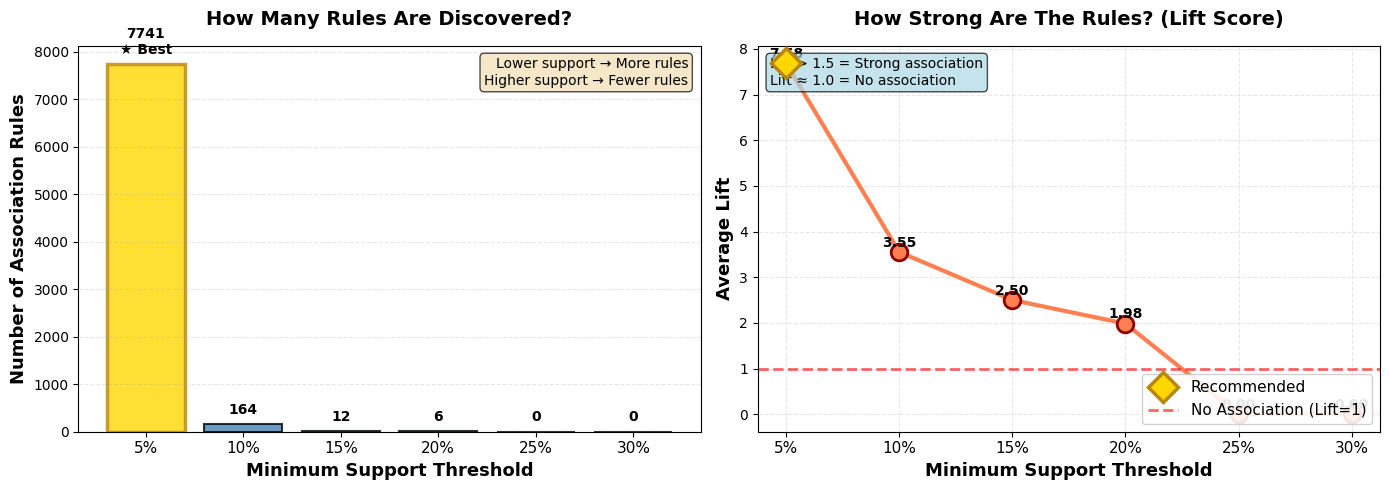


SUMMARY TABLE (Use this in your report)
Min Support  Total Rules  Strong Rules (Lift≥1.5) Avg Lift
         5%         7741                     7698     7.68
        10%          164                      158     3.55
        15%           12                       12     2.50
        20%            6                        6     1.98
        25%            0                        0     0.00
        30%            0                        0     0.00


✓ RECOMMENDATION FOR YOUR REPORT

CHOSEN THRESHOLD: min_support = 5%

WHY THIS CHOICE?
✓ Found 7741 association rules total
✓ 7698 of these are strong rules (lift ≥ 1.5)
✓ Average lift of 7.68 shows meaningful associations
✓ Balanced between finding enough patterns vs. avoiding noise

WHAT TO WRITE IN YOUR REPORT:
"We tested support thresholds from 5% to 30%. Lower thresholds find more rules 
but may include noise. Higher thresholds are more selective but may miss patterns.
We selected 5% as it provides the best balance, yielding 7741 rul

In [ ]:
# Simple and Clear Visualization for Task 1: Symptom Co-occurrence Analysis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define range of min_support values to test
support_values = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

# Store metrics for comparison
results = []

print("Testing different min_support values...\n")
print("=" * 80)

for min_sup in support_values:
    # Fit Apriori with current min_support
    temp_miner = AprioriMiner(min_support=min_sup)
    temp_miner.fit(transactions)
    temp_miner.generate_rules(min_confidence=0.5)

    # Collect metrics
    total_itemsets = len(temp_miner.all_frequent_itemsets)
    total_rules = len(temp_miner.association_rules)

    # Itemset size distribution
    size_dist = {}
    for k in temp_miner.frequent_itemsets.keys():
        size_dist[k] = len(temp_miner.frequent_itemsets[k])

    # Rule quality metrics
    if total_rules > 0:
        rules_df_temp = pd.DataFrame(temp_miner.association_rules)
        avg_confidence = rules_df_temp["confidence"].mean()
        avg_lift = rules_df_temp["lift"].mean()
        max_lift = rules_df_temp["lift"].max()
        strong_rules = len(rules_df_temp[rules_df_temp["lift"] >= 1.5])
    else:
        avg_confidence = avg_lift = max_lift = strong_rules = 0

    # Store results
    results.append(
        {
            "min_support": min_sup,
            "min_support_count": int(min_sup * len(transactions)),
            "total_itemsets": total_itemsets,
            "total_rules": total_rules,
            "size_distribution": size_dist,
            "avg_confidence": avg_confidence,
            "avg_lift": avg_lift,
            "max_lift": max_lift,
            "strong_rules": strong_rules,
        }
    )

    # Print summary
    print(f"\nmin_support = {min_sup} (≥{int(min_sup * len(transactions))} diseases)")
    print(f"  Frequent itemsets: {total_itemsets}")
    print(f"  Association rules: {total_rules}")
    print(f"  Strong rules (lift≥1.5): {strong_rules}")
    if total_rules > 0:
        print(f"  Avg confidence: {avg_confidence:.3f}")
        print(f"  Avg lift: {avg_lift:.3f}")
    print("-" * 80)

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("COMPARISON SUMMARY")
print("=" * 80)
print(
    comparison_df[
        [
            "min_support",
            "min_support_count",
            "total_itemsets",
            "total_rules",
            "strong_rules",
            "avg_lift",
        ]
    ].to_string(index=False)
)

# ============================================================================
# SIMPLE AND CLEAR VISUALIZATION: 2 Easy-to-Read Plots
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- PLOT 1: Simple Bar Chart - Number of Rules Found ---
ax1 = axes[0]

x_labels = [f"{s:.0%}" for s in comparison_df["min_support"]]
x_pos = np.arange(len(x_labels))

bars = ax1.bar(
    x_pos,
    comparison_df["total_rules"],
    color="steelblue",
    alpha=0.8,
    edgecolor="black",
    linewidth=1.5,
)

# Highlight the bar with most strong rules
best_idx = comparison_df["strong_rules"].idxmax()
bars[best_idx].set_color("gold")
bars[best_idx].set_edgecolor("darkgoldenrod")
bars[best_idx].set_linewidth(2.5)

ax1.set_xlabel("Minimum Support Threshold", fontsize=13, fontweight="bold")
ax1.set_ylabel("Number of Association Rules", fontsize=13, fontweight="bold")
ax1.set_title("How Many Rules Are Discovered?", fontsize=14, fontweight="bold", pad=15)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels, fontsize=11)
ax1.grid(axis="y", alpha=0.3, linestyle="--")

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, comparison_df["total_rules"])):
    height = bar.get_height()
    label_text = f"{int(count)}"
    if i == best_idx:
        label_text += "\n★ Best"
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + max(comparison_df["total_rules"]) * 0.02,
        label_text,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# Add interpretation box
textstr = "Lower support → More rules\nHigher support → Fewer rules"
props = dict(boxstyle="round", facecolor="wheat", alpha=0.7)
ax1.text(
    0.98,
    0.97,
    textstr,
    transform=ax1.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=props,
)

# --- PLOT 2: Simple Line Chart - Rule Quality (Lift) ---
ax2 = axes[1]

# Plot line
line = ax2.plot(
    x_pos,
    comparison_df["avg_lift"],
    "o-",
    linewidth=3,
    markersize=12,
    color="coral",
    markeredgecolor="darkred",
    markeredgewidth=2,
)

# Highlight best point
ax2.plot(
    best_idx,
    comparison_df.loc[best_idx, "avg_lift"],
    "D",
    markersize=15,
    color="gold",
    markeredgecolor="darkgoldenrod",
    markeredgewidth=2.5,
    label="Recommended",
    zorder=10,
)

# Add baseline reference
ax2.axhline(
    y=1.0,
    color="red",
    linestyle="--",
    linewidth=2,
    alpha=0.6,
    label="No Association (Lift=1)",
)

ax2.set_xlabel("Minimum Support Threshold", fontsize=13, fontweight="bold")
ax2.set_ylabel("Average Lift", fontsize=13, fontweight="bold")
ax2.set_title(
    "How Strong Are The Rules? (Lift Score)", fontsize=14, fontweight="bold", pad=15
)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x_labels, fontsize=11)
ax2.grid(alpha=0.3, linestyle="--")
ax2.legend(loc="lower right", fontsize=11, framealpha=0.9)

# Add value labels
for i, (x, y) in enumerate(zip(x_pos, comparison_df["avg_lift"])):
    ax2.text(
        x,
        y + 0.05,
        f"{y:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# Add interpretation box
textstr = "Lift > 1.5 = Strong association\nLift ≈ 1.0 = No association"
props = dict(boxstyle="round", facecolor="lightblue", alpha=0.7)
ax2.text(
    0.02,
    0.97,
    textstr,
    transform=ax2.transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="left",
    bbox=props,
)

plt.tight_layout()
# plt.savefig('task1_simple_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================================
# SIMPLE SUMMARY TABLE FOR REPORT
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY TABLE (Use this in your report)")
print("=" * 80)

summary_table = comparison_df[
    ["min_support", "total_rules", "strong_rules", "avg_lift"]
].copy()
summary_table.columns = [
    "Min Support",
    "Total Rules",
    "Strong Rules (Lift≥1.5)",
    "Avg Lift",
]
summary_table["Min Support"] = summary_table["Min Support"].apply(lambda x: f"{x:.0%}")
summary_table["Avg Lift"] = summary_table["Avg Lift"].apply(lambda x: f"{x:.2f}")

print(summary_table.to_string(index=False))
print()

# ============================================================================
# CLEAR RECOMMENDATION
# ============================================================================

print("\n" + "=" * 80)
print("✓ RECOMMENDATION FOR YOUR REPORT")
print("=" * 80)

best_support = comparison_df.loc[best_idx, "min_support"]
best_total = comparison_df.loc[best_idx, "total_rules"]
best_strong = comparison_df.loc[best_idx, "strong_rules"]
best_lift = comparison_df.loc[best_idx, "avg_lift"]

print(f"""
CHOSEN THRESHOLD: min_support = {best_support:.0%}

WHY THIS CHOICE?
✓ Found {best_total} association rules total
✓ {best_strong} of these are strong rules (lift ≥ 1.5)
✓ Average lift of {best_lift:.2f} shows meaningful associations
✓ Balanced between finding enough patterns vs. avoiding noise

WHAT TO WRITE IN YOUR REPORT:
"We tested support thresholds from 5% to 30%. Lower thresholds find more rules 
but may include noise. Higher thresholds are more selective but may miss patterns.
We selected {best_support:.0%} as it provides the best balance, yielding {best_total} rules 
with an average lift of {best_lift:.2f}, indicating strong symptom co-occurrence patterns."
""")

print("\n" + "=" * 80)
print("NEXT STEPS")
print("=" * 80)
print(
    """
1. Use min_support={} for your final Apriori analysis
2. Include the 2 simple plots above in your report
3. Show 5-10 example rules with interpretation
4. Discuss what the patterns mean for disease diagnosis
""".format(best_support)
)

Testing different min_support values...

Fitting Apriori with min_support=0.05 (count=3)
Total transactions: 41
Generating 1-itemsets...
  Found 31 frequent 1-itemsets
Generating 2-itemsets...
  Found 104 frequent 2-itemsets
Generating 3-itemsets...
  Found 153 frequent 3-itemsets
Generating 4-itemsets...
  Found 143 frequent 4-itemsets
Generating 5-itemsets...
  Found 86 frequent 5-itemsets
Generating 6-itemsets...
  Found 36 frequent 6-itemsets
Generating 7-itemsets...
  Found 9 frequent 7-itemsets
Generating 8-itemsets...
  Found 1 frequent 8-itemsets
Total frequent itemsets: 563

min_support = 0.05 (≥2 diseases)
  Frequent itemsets: 563
  Association rules: 7741
  Itemset distribution: {1: 31, 2: 104, 3: 153, 4: 143, 5: 86, 6: 36, 7: 9, 8: 1}
  Avg confidence: 0.827
  Avg lift: 7.683
  Max lift: 13.667
  Perfect confidence rules: 3852
--------------------------------------------------------------------------------
Fitting Apriori with min_support=0.1 (count=5)
Total transactions: 4

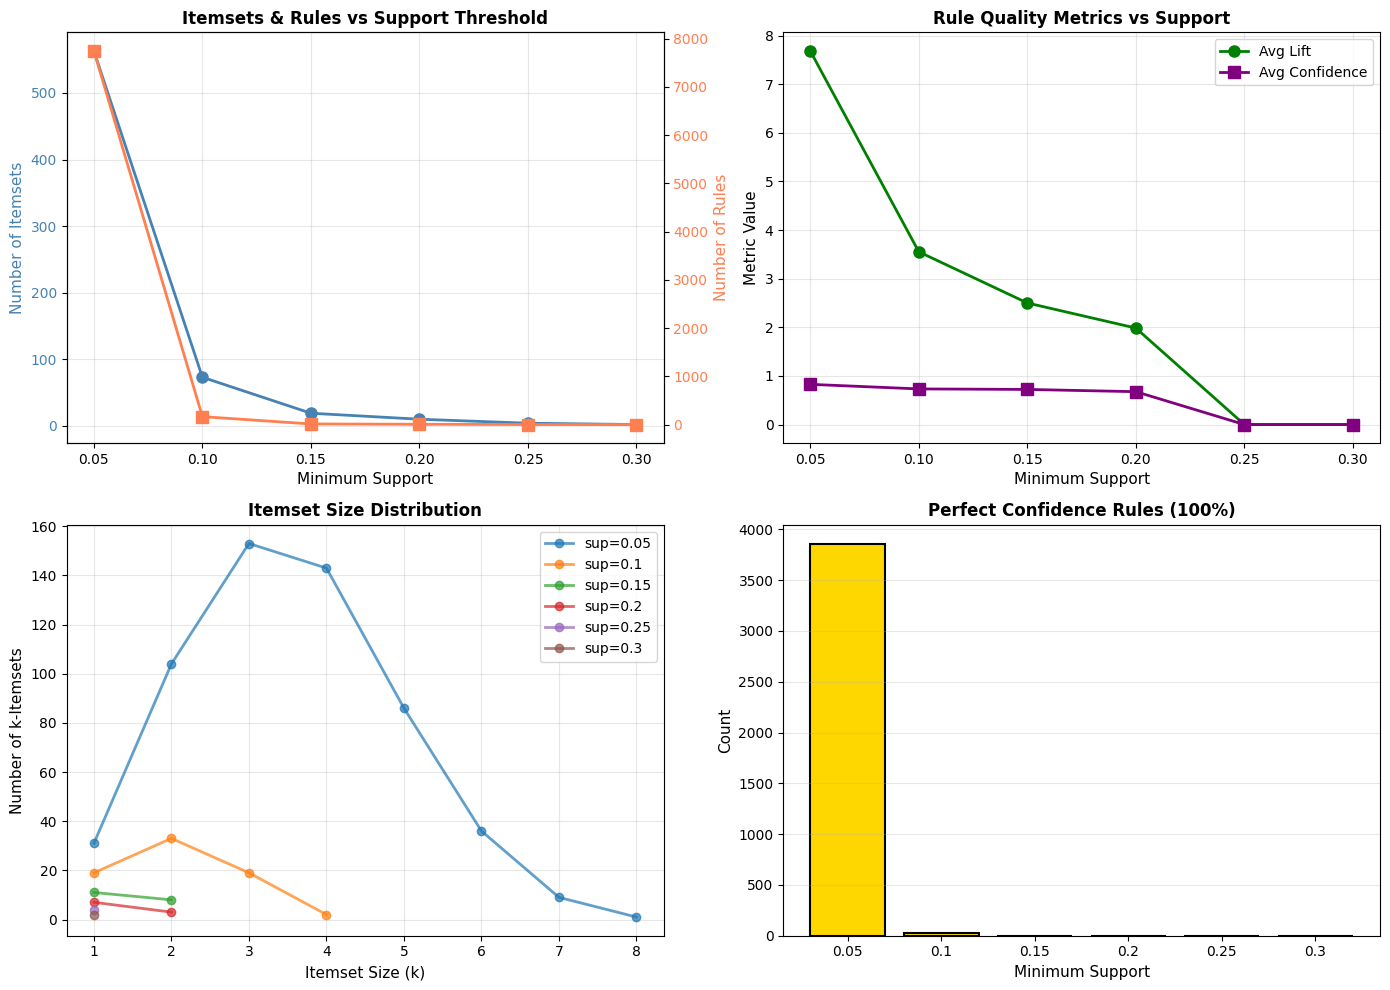


RECOMMENDATION

Based on the analysis:
• Lower min_support (0.05-0.10): More itemsets/rules, good for discovering rare patterns
• Medium min_support (0.15-0.20): Balanced coverage, focuses on moderately common patterns
• Higher min_support (0.25-0.30): Fewer but stronger patterns, very common symptoms only

Consider:
  - min_support=0.10 gives good balance between coverage and significance
  - Adjust based on whether you want to capture rare symptom combinations
  - Higher lift values indicate stronger, more interesting associations


In [24]:
# Evaluate different min_support values to find optimal threshold
import numpy as np

# Define range of min_support values to test
support_values = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

# Store metrics for comparison
results = []

print("Testing different min_support values...\n")
print("=" * 80)

for min_sup in support_values:
    # Fit Apriori with current min_support
    temp_miner = AprioriMiner(min_support=min_sup)
    temp_miner.fit(transactions)
    temp_miner.generate_rules(min_confidence=0.5)

    # Collect metrics
    total_itemsets = len(temp_miner.all_frequent_itemsets)
    total_rules = len(temp_miner.association_rules)

    # Itemset size distribution - FIXED: iterate over the dict keys
    size_dist = {}
    for k in temp_miner.frequent_itemsets.keys():
        size_dist[k] = len(temp_miner.frequent_itemsets[k])

    # Rule quality metrics
    if total_rules > 0:
        rules_df_temp = pd.DataFrame(temp_miner.association_rules)
        avg_confidence = rules_df_temp["confidence"].mean()
        avg_lift = rules_df_temp["lift"].mean()
        max_lift = rules_df_temp["lift"].max()
        perfect_conf_rules = len(rules_df_temp[rules_df_temp["confidence"] == 1.0])
    else:
        avg_confidence = avg_lift = max_lift = perfect_conf_rules = 0

    # Store results
    results.append(
        {
            "min_support": min_sup,
            "min_support_count": int(min_sup * len(transactions)),
            "total_itemsets": total_itemsets,
            "total_rules": total_rules,
            "size_distribution": size_dist,
            "avg_confidence": avg_confidence,
            "avg_lift": avg_lift,
            "max_lift": max_lift,
            "perfect_conf_rules": perfect_conf_rules,
        }
    )

    # Print summary
    print(f"\nmin_support = {min_sup} (≥{int(min_sup * len(transactions))} diseases)")
    print(f"  Frequent itemsets: {total_itemsets}")
    print(f"  Association rules: {total_rules}")
    print(f"  Itemset distribution: {size_dist}")
    if total_rules > 0:
        print(f"  Avg confidence: {avg_confidence:.3f}")
        print(f"  Avg lift: {avg_lift:.3f}")
        print(f"  Max lift: {max_lift:.3f}")
        print(f"  Perfect confidence rules: {perfect_conf_rules}")
    print("-" * 80)

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
print("\n" + "=" * 80)
print("COMPARISON SUMMARY")
print("=" * 80)
print(
    comparison_df[
        [
            "min_support",
            "min_support_count",
            "total_itemsets",
            "total_rules",
            "avg_confidence",
            "avg_lift",
            "max_lift",
        ]
    ].to_string(index=False)
)

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Itemsets and Rules vs min_support
ax1 = axes[0, 0]
ax1.plot(
    comparison_df["min_support"],
    comparison_df["total_itemsets"],
    "o-",
    linewidth=2,
    markersize=8,
    label="Frequent Itemsets",
    color="steelblue",
)
ax1.set_xlabel("Minimum Support", fontsize=11)
ax1.set_ylabel("Number of Itemsets", fontsize=11, color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.grid(alpha=0.3)

ax1_twin = ax1.twinx()
ax1_twin.plot(
    comparison_df["min_support"],
    comparison_df["total_rules"],
    "s-",
    linewidth=2,
    markersize=8,
    label="Association Rules",
    color="coral",
)
ax1_twin.set_ylabel("Number of Rules", fontsize=11, color="coral")
ax1_twin.tick_params(axis="y", labelcolor="coral")
ax1.set_title("Itemsets & Rules vs Support Threshold", fontsize=12, fontweight="bold")

# Plot 2: Average Lift and Confidence
ax2 = axes[0, 1]
ax2.plot(
    comparison_df["min_support"],
    comparison_df["avg_lift"],
    "o-",
    linewidth=2,
    markersize=8,
    label="Avg Lift",
    color="green",
)
ax2.plot(
    comparison_df["min_support"],
    comparison_df["avg_confidence"],
    "s-",
    linewidth=2,
    markersize=8,
    label="Avg Confidence",
    color="purple",
)
ax2.set_xlabel("Minimum Support", fontsize=11)
ax2.set_ylabel("Metric Value", fontsize=11)
ax2.set_title("Rule Quality Metrics vs Support", fontsize=12, fontweight="bold")
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: Itemset size distribution for each min_support
ax3 = axes[1, 0]
for result in results:
    sizes = sorted(result["size_distribution"].keys())
    counts = [result["size_distribution"][s] for s in sizes]
    ax3.plot(
        sizes,
        counts,
        "o-",
        linewidth=2,
        markersize=6,
        label=f"sup={result['min_support']}",
        alpha=0.7,
    )
ax3.set_xlabel("Itemset Size (k)", fontsize=11)
ax3.set_ylabel("Number of k-Itemsets", fontsize=11)
ax3.set_title("Itemset Size Distribution", fontsize=12, fontweight="bold")
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Perfect confidence rules
ax4 = axes[1, 1]
ax4.bar(
    comparison_df["min_support"].astype(str),
    comparison_df["perfect_conf_rules"],
    color="gold",
    edgecolor="black",
    linewidth=1.5,
)
ax4.set_xlabel("Minimum Support", fontsize=11)
ax4.set_ylabel("Count", fontsize=11)
ax4.set_title("Perfect Confidence Rules (100%)", fontsize=12, fontweight="bold")
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Recommendation
print("\n" + "=" * 80)
print("RECOMMENDATION")
print("=" * 80)
print("\nBased on the analysis:")
print(
    "• Lower min_support (0.05-0.10): More itemsets/rules, good for discovering rare patterns"
)
print(
    "• Medium min_support (0.15-0.20): Balanced coverage, focuses on moderately common patterns"
)
print(
    "• Higher min_support (0.25-0.30): Fewer but stronger patterns, very common symptoms only"
)
print("\nConsider:")
print("  - min_support=0.10 gives good balance between coverage and significance")
print("  - Adjust based on whether you want to capture rare symptom combinations")
print("  - Higher lift values indicate stronger, more interesting associations")

In [8]:
miner = AprioriMiner(min_support=0.1)  # Adjust min_support as needed
miner.fit(transactions)

# Generate association rules
miner.generate_rules(min_confidence=0.5)

# Print results
miner.print_summary()

Fitting Apriori with min_support=0.1 (count=5)
Total transactions: 41
Generating 1-itemsets...
  Found 19 frequent 1-itemsets
Generating 2-itemsets...
  Found 33 frequent 2-itemsets
Generating 3-itemsets...
  Found 19 frequent 3-itemsets
Generating 4-itemsets...
  Found 2 frequent 4-itemsets
Generating 5-itemsets...
  Found 0 frequent 5-itemsets
Total frequent itemsets: 73

APRIORI ALGORITHM - RESULTS SUMMARY

Min Support: 0.1
Total Transactions: 41
Total Frequent Itemsets: 73

Itemsets by Size:
  1-itemsets: 19
  2-itemsets: 33
  3-itemsets: 19
  4-itemsets: 2

Association Rules: 164

Top 10 Rules by Confidence:

  1. {yellowing_of_eyes} -> {loss_of_appetite}
     Confidence: 1.000
     Support: 0.171
     Lift: 4.100

  2. {malaise} -> {fatigue}
     Confidence: 1.000
     Support: 0.146
     Lift: 2.412

  3. {dark_urine} -> {yellowish_skin}
     Confidence: 1.000
     Support: 0.122
     Lift: 5.125

  4. {dark_urine} -> {abdominal_pain}
     Confidence: 1.000
     Support: 0.122
 

## 1.6 Analysis

### Most Common Symptoms

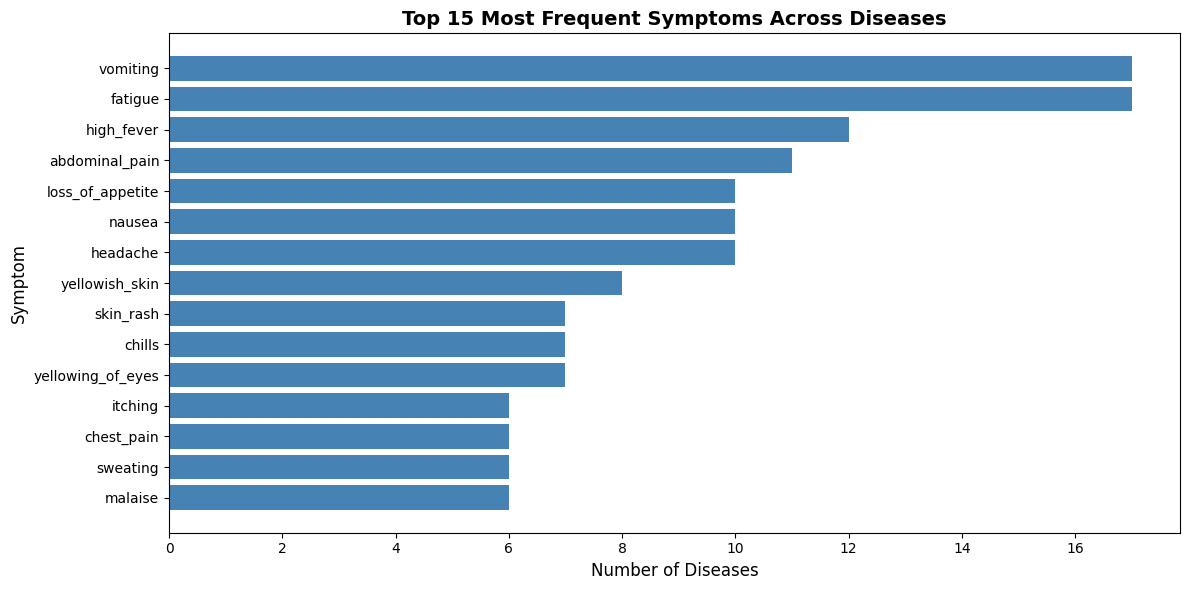

Most common: 'vomiting' appears in 17/41 diseases (41.5%)


In [9]:
single_symptoms = miner.get_frequent_itemsets(k=1)
symptoms = [list(itemset)[0] for itemset, count in single_symptoms[:15]]
counts = [count for itemset, count in single_symptoms[:15]]

plt.figure(figsize=(12, 6))
plt.barh(symptoms, counts, color="steelblue")
plt.xlabel("Number of Diseases", fontsize=12)
plt.ylabel("Symptom", fontsize=12)
plt.title(
    "Top 15 Most Frequent Symptoms Across Diseases", fontsize=14, fontweight="bold"
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(
    f"Most common: '{symptoms[0]}' appears in {counts[0]}/{len(transactions)} diseases ({counts[0] / len(transactions) * 100:.1f}%)"
)

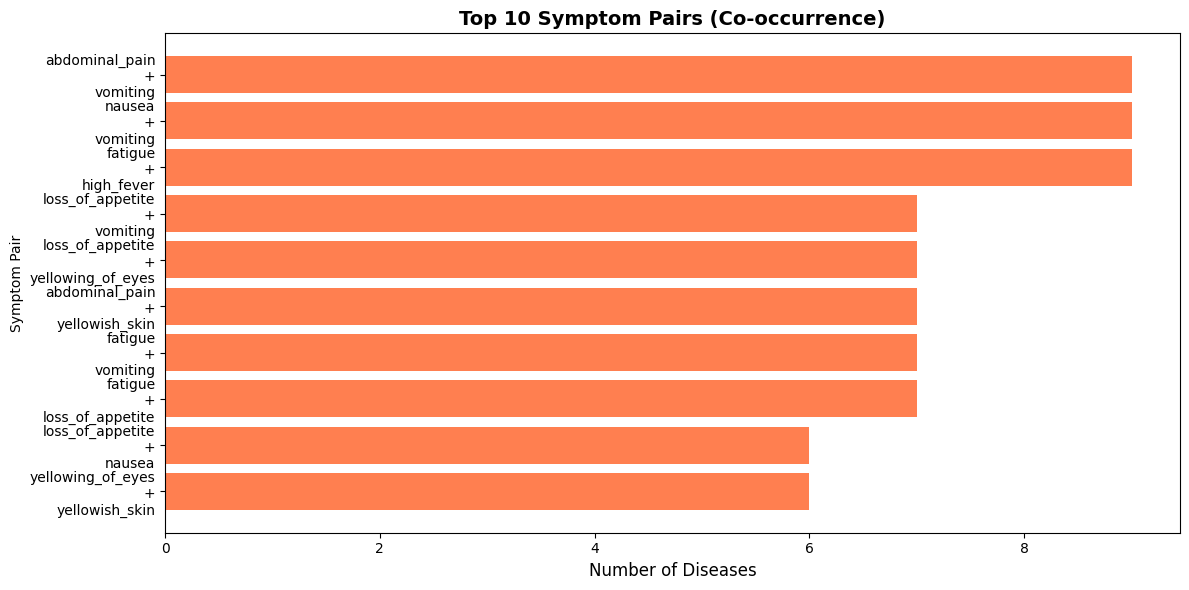

Strongest pair: ['abdominal_pain', 'vomiting'] co-occurs in 9 diseases


In [10]:
# Cell 2: Strongest Symptom Pairs
pairs = miner.get_frequent_itemsets(k=2)
pair_labels = [
    f"{sorted(list(itemset))[0]}\n+\n{sorted(list(itemset))[1]}"
    for itemset, _ in pairs[:10]
]
pair_counts = [count for _, count in pairs[:10]]

plt.figure(figsize=(12, 6))
plt.barh(pair_labels, pair_counts, color="coral")
plt.xlabel("Number of Diseases", fontsize=12)
plt.ylabel("Symptom Pair", fontsize=10)
plt.title("Top 10 Symptom Pairs (Co-occurrence)", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Strongest pair: {list(pairs[0][0])} co-occurs in {pairs[0][1]} diseases")

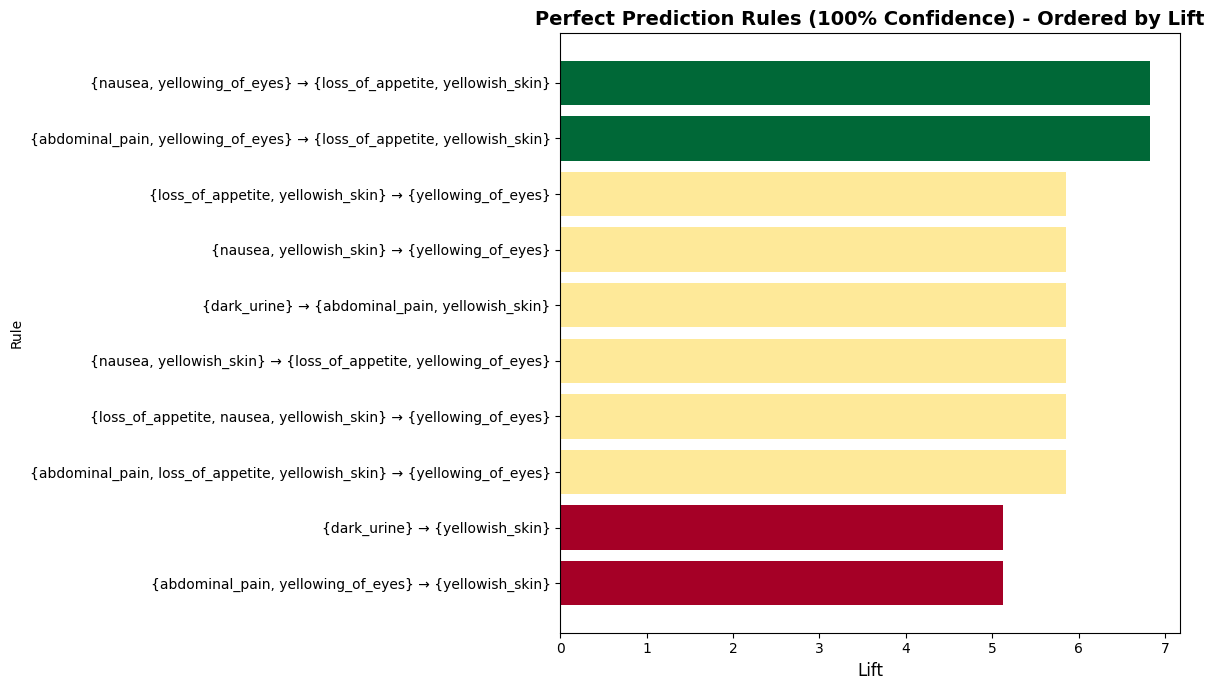

Found 10 perfect confidence rules (if antecedent present, consequent is ALWAYS present)


In [ ]:
# Cell 3: Perfect Confidence Rules (100% Predictive)
rules_df = pd.DataFrame(miner.association_rules)
perfect = rules_df[rules_df["confidence"] == 1.0].nlargest(10, "lift")

rule_labels = []
lifts = []
for rule in perfect.itertuples():
    ant = ", ".join(sorted(rule.antecedent))
    con = ", ".join(sorted(rule.consequent))
    rule_labels.append(f"{{{ant}}} → {{{con}}}")
    lifts.append(rule.lift)

plt.figure(figsize=(12, 7))
colors = plt.cm.RdYlGn(
    [(lift - min(lifts)) / (max(lifts) - min(lifts)) for lift in lifts]
)
plt.barh(rule_labels, lifts, color=colors)
plt.xlabel("Lift", fontsize=12)
plt.ylabel("Rule", fontsize=10)
plt.title(
    "Perfect Prediction Rules (100% Confidence) - Ordered by Lift",
    fontsize=14,
    fontweight="bold",
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(
    f"Found {len(perfect)} perfect confidence rules (if antecedent present, consequent is ALWAYS present)"
)

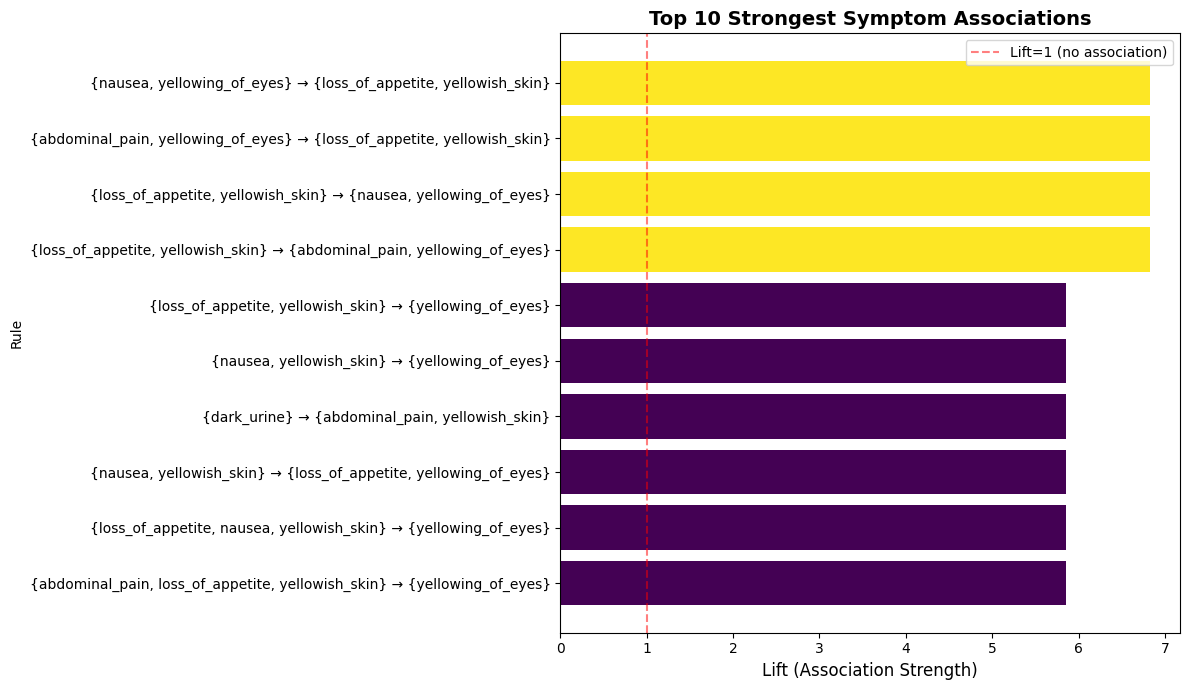

Highest lift: 6.83 means symptoms occur 6.8x more often together than by chance


In [ ]:
# Cell 4: Strongest Associations (Highest Lift)
rules_df = pd.DataFrame(miner.association_rules)
top_lift = rules_df.nlargest(10, "lift")

rule_labels = []
lifts = []
for rule in top_lift.itertuples():
    ant = ", ".join(sorted(rule.antecedent))
    con = ", ".join(sorted(rule.consequent))
    rule_labels.append(f"{{{ant}}} → {{{con}}}")
    lifts.append(rule.lift)

plt.figure(figsize=(12, 7))
colors = plt.cm.viridis(
    [(lift - min(lifts)) / (max(lifts) - min(lifts)) for lift in lifts]
)
plt.barh(rule_labels, lifts, color=colors)
plt.xlabel("Lift (Association Strength)", fontsize=12)
plt.ylabel("Rule", fontsize=10)
plt.title("Top 10 Strongest Symptom Associations", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.axvline(
    x=1, color="red", linestyle="--", alpha=0.5, label="Lift=1 (no association)"
)
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"Highest lift: {lifts[0]:.2f} means symptoms occur {lifts[0]:.1f}x more often together than by chance"
)

In [13]:
# METRICS SUMMARY
all_symptoms = set()
for transaction in transactions:
    all_symptoms.update(transaction)

itemset_counts = {k: len(v) for k, v in miner.frequent_itemsets.items()}


print(f"Number of Diseases: {len(transactions)}")
print(f"Total Unique Symptoms: {len(all_symptoms)}")
print(f"Min Support Threshold: {miner.min_support}")
print(f"Min Support Count: {int(np.ceil(miner.min_support * len(transactions)))}")
print(f"Total Frequent Itemsets: {len(miner.all_frequent_itemsets)}")
print(f"Association Rules Generated: {len(miner.association_rules)}")

print("\nFrequent Itemsets by Size:")
for k, count in itemset_counts.items():
    print(f"  {k}-itemsets: {count}")

Number of Diseases: 41
Total Unique Symptoms: 129
Min Support Threshold: 0.1
Min Support Count: 5
Total Frequent Itemsets: 73
Association Rules Generated: 164

Frequent Itemsets by Size:
  1-itemsets: 19
  2-itemsets: 33
  3-itemsets: 19
  4-itemsets: 2


In [14]:
# TOP ASSOCIATION RULES TABLE
min_lift = 1.2
top_n = 15

# Filter and sort rules
filtered_rules = [r for r in miner.association_rules if r["lift"] >= min_lift]
top_rules = sorted(
    filtered_rules, key=lambda x: (x["lift"], x["confidence"]), reverse=True
)[:top_n]

# Create DataFrame
rules_data = []
for rule in top_rules:
    antecedent_str = ", ".join(sorted(rule["antecedent"]))
    consequent_str = ", ".join(sorted(rule["consequent"]))

    rules_data.append(
        {
            "Antecedent": antecedent_str,
            "Consequent": consequent_str,
            "Support": f"{rule['support']:.3f}",
            "Confidence": f"{rule['confidence']:.3f}",
            "Lift": f"{rule['lift']:.3f}",
        }
    )

df_rules = pd.DataFrame(rules_data)

print("\n" + "=" * 80)
print(f"TOP {top_n} ASSOCIATION RULES (Lift >= {min_lift})")
print("=" * 80)
print(df_rules.to_string(index=True))


TOP 15 ASSOCIATION RULES (Lift >= 1.2)
                                          Antecedent                                Consequent Support Confidence   Lift
0                          nausea, yellowing_of_eyes          loss_of_appetite, yellowish_skin   0.122      1.000  6.833
1                  abdominal_pain, yellowing_of_eyes          loss_of_appetite, yellowish_skin   0.122      1.000  6.833
2                   loss_of_appetite, yellowish_skin                 nausea, yellowing_of_eyes   0.122      0.833  6.833
3                   loss_of_appetite, yellowish_skin         abdominal_pain, yellowing_of_eyes   0.122      0.833  6.833
4                   loss_of_appetite, yellowish_skin                         yellowing_of_eyes   0.146      1.000  5.857
5                             nausea, yellowish_skin                         yellowing_of_eyes   0.122      1.000  5.857
6                                         dark_urine            abdominal_pain, yellowish_skin   0.122      1.000

In [15]:
# CLINICAL INTERPRETATION OF TOP RULES
print("\n" + "=" * 80)
print("CLINICAL INTERPRETATION OF TOP 5 RULES")
print("=" * 80)

for i, rule in enumerate(top_rules[:5], 1):
    antecedent = ", ".join(sorted(rule["antecedent"]))
    consequent = ", ".join(sorted(rule["consequent"]))

    print(f"\n{i}. {{{antecedent}}} → {{{consequent}}}")
    print(
        f"   Support: {rule['support']:.3f} | Confidence: {rule['confidence']:.3f} | Lift: {rule['lift']:.3f}"
    )
    print(
        f"   → {rule['confidence'] * 100:.1f}% of diseases with [{antecedent}] also present [{consequent}]"
    )
    print(f"   → This association is {rule['lift']:.2f}x stronger than random chance")


CLINICAL INTERPRETATION OF TOP 5 RULES

1. {nausea, yellowing_of_eyes} → {loss_of_appetite, yellowish_skin}
   Support: 0.122 | Confidence: 1.000 | Lift: 6.833
   → 100.0% of diseases with [nausea, yellowing_of_eyes] also present [loss_of_appetite, yellowish_skin]
   → This association is 6.83x stronger than random chance

2. {abdominal_pain, yellowing_of_eyes} → {loss_of_appetite, yellowish_skin}
   Support: 0.122 | Confidence: 1.000 | Lift: 6.833
   → 100.0% of diseases with [abdominal_pain, yellowing_of_eyes] also present [loss_of_appetite, yellowish_skin]
   → This association is 6.83x stronger than random chance

3. {loss_of_appetite, yellowish_skin} → {nausea, yellowing_of_eyes}
   Support: 0.122 | Confidence: 0.833 | Lift: 6.833
   → 83.3% of diseases with [loss_of_appetite, yellowish_skin] also present [nausea, yellowing_of_eyes]
   → This association is 6.83x stronger than random chance

4. {loss_of_appetite, yellowish_skin} → {abdominal_pain, yellowing_of_eyes}
   Support: 0

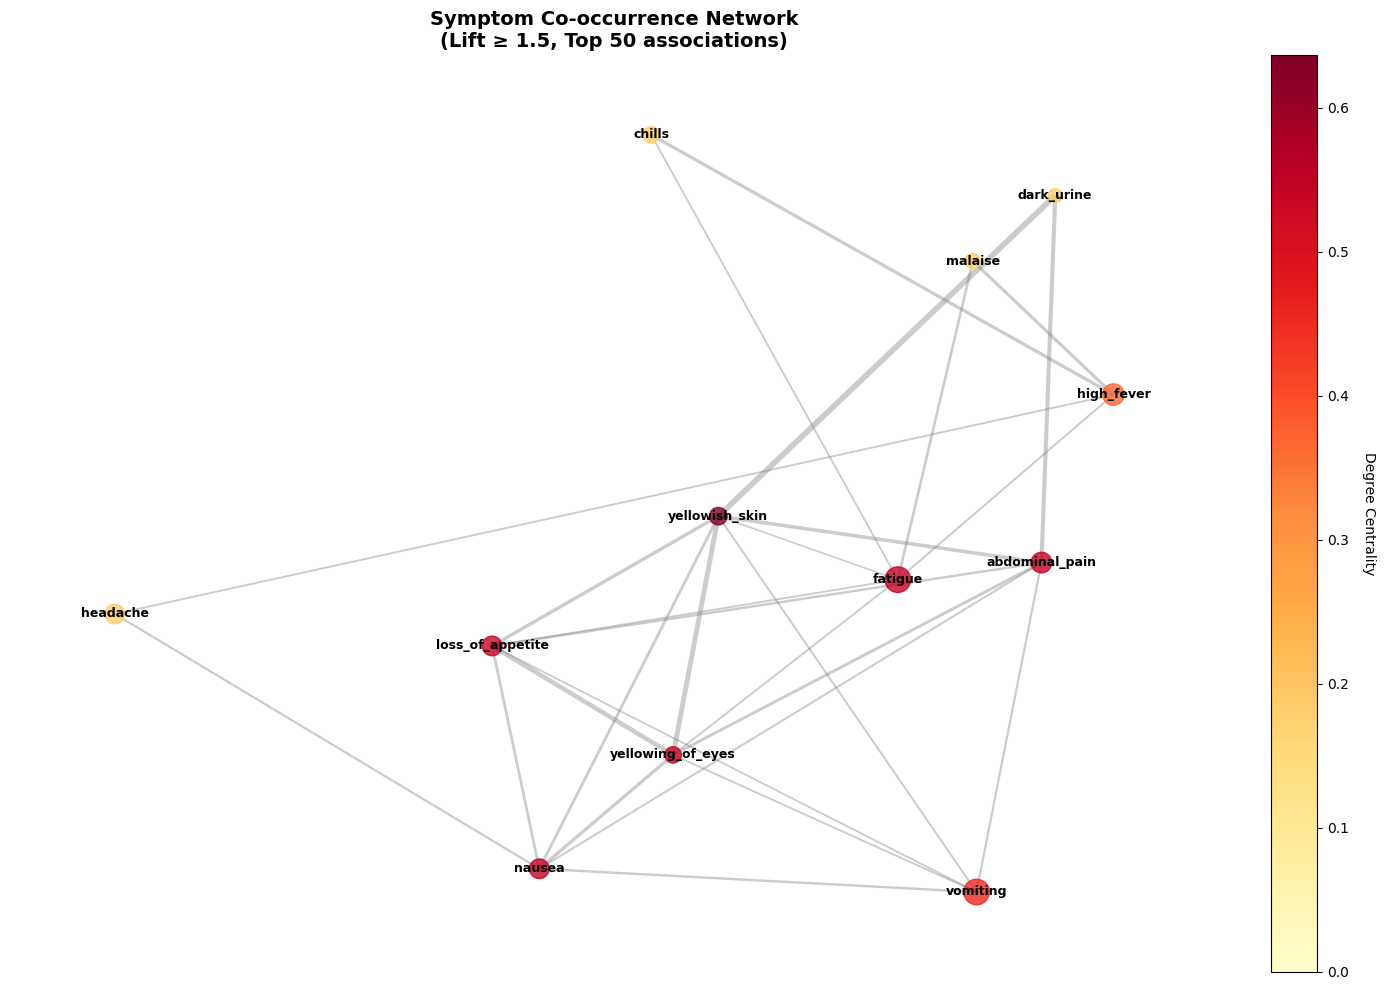


✓ Saved to: symptom_network.png
Nodes: 12 | Edges: 27


In [ ]:
# SYMPTOM CO-OCCURRENCE NETWORK
min_lift_network = 1.5
max_edges = 50

# Filter strong rules (1→1 for cleaner network)
strong_rules = [
    r
    for r in miner.association_rules
    if r["lift"] >= min_lift_network
    and len(r["antecedent"]) == 1
    and len(r["consequent"]) == 1
]
strong_rules = sorted(strong_rules, key=lambda x: x["lift"], reverse=True)[:max_edges]

# Build graph
G = nx.Graph()

# Get symptom frequencies for node sizing
symptom_freq = {}
for itemset, count in miner.all_frequent_itemsets:
    if len(itemset) == 1:
        symptom = list(itemset)[0]
        symptom_freq[symptom] = count

# Add edges
for rule in strong_rules:
    source = list(rule["antecedent"])[0]
    target = list(rule["consequent"])[0]

    if source not in G:
        G.add_node(source, frequency=symptom_freq.get(source, 0))
    if target not in G:
        G.add_node(target, frequency=symptom_freq.get(target, 0))

    G.add_edge(source, target, weight=rule["lift"], lift=rule["lift"])

# Visualize
plt.figure(figsize=(14, 10))

pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Node sizes by frequency
node_sizes = [G.nodes[node].get("frequency", 1) * 20 for node in G.nodes()]

# Edge widths by lift
edge_widths = [G[u][v]["lift"] * 0.8 for u, v in G.edges()]

# Node colors by centrality
centrality = nx.degree_centrality(G)
node_colors = [centrality[node] for node in G.nodes()]

# Draw
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="YlOrRd",
    alpha=0.8,
    vmin=0,
    vmax=max(centrality.values()),
)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.4, edge_color="gray")
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

plt.title(
    f"Symptom Co-occurrence Network\n(Lift ≥ {min_lift_network}, Top {max_edges} associations)",
    fontsize=14,
    fontweight="bold",
)
plt.axis("off")

# Colorbar
sm = plt.cm.ScalarMappable(
    cmap="YlOrRd", norm=plt.Normalize(vmin=0, vmax=max(centrality.values()))
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
cbar.set_label("Degree Centrality", rotation=270, labelpad=20)

plt.tight_layout()
# plt.savefig('symptom_network.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved to: symptom_network.png")
print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

In [18]:
# KEY INSIGHTS
print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# 1. Clinical Coherence
print("\n1. CLINICAL COHERENCE - Common Symptom Combinations")
print("-" * 80)
for rule in top_rules[:3]:
    ant = ", ".join(sorted(rule["antecedent"]))
    cons = ", ".join(sorted(rule["consequent"]))
    print(
        f"   • {{{ant}}} → {{{cons}}} (Conf: {rule['confidence']:.2f}, Lift: {rule['lift']:.2f})"
    )
print(
    f"\n   These patterns show strong predictive relationships with confidence >{top_rules[0]['confidence']:.1%}."
)

# 2. Symptom Clusters
print("\n2. SYMPTOM CLUSTERS")
print("-" * 80)
three_itemsets = miner.frequent_itemsets.get(3, [])
if three_itemsets:
    print(f"   Found {len(three_itemsets)} frequent 3-symptom clusters. Top clusters:")
    for itemset, count in three_itemsets[:3]:
        symptoms = ", ".join(sorted(itemset))
        support = count / len(transactions)
        print(f"   • {{{symptoms}}} - Support: {support:.2%}")
else:
    print("   No 3-itemsets found at current support threshold.")

# 3. Hub Symptoms
print("\n3. HUB SYMPTOMS - Central Connectors")
print("-" * 80)
top_hubs = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("   Most frequently co-occurring symptoms:")
for symptom, cent in top_hubs:
    degree = G.degree(symptom)
    print(
        f"   • '{symptom}' - Connected to {degree} other symptoms (centrality: {cent:.3f})"
    )
print("\n   Hub symptoms likely represent common, non-specific manifestations.")

# 4. Rare but Strong Associations
print("\n4. RARE BUT STRONG ASSOCIATIONS")
print("-" * 80)
rare_strong = [
    r for r in miner.association_rules if r["support"] < 0.1 and r["lift"] > 2.0
]
if rare_strong:
    rare_strong = sorted(rare_strong, key=lambda x: x["lift"], reverse=True)[:3]
    print("   High-lift, low-support rules (potential disease-specific markers):")
    for rule in rare_strong:
        ant = ", ".join(sorted(rule["antecedent"]))
        cons = ", ".join(sorted(rule["consequent"]))
        print(
            f"   • {{{ant}}} → {{{cons}}} | Support: {rule['support']:.2%}, Lift: {rule['lift']:.2f}"
        )
else:
    print("   No rare but strong associations found at current thresholds.")

print("\n" + "=" * 80)


KEY INSIGHTS

1. CLINICAL COHERENCE - Common Symptom Combinations
--------------------------------------------------------------------------------
   • {nausea, yellowing_of_eyes} → {loss_of_appetite, yellowish_skin} (Conf: 1.00, Lift: 6.83)
   • {abdominal_pain, yellowing_of_eyes} → {loss_of_appetite, yellowish_skin} (Conf: 1.00, Lift: 6.83)
   • {loss_of_appetite, yellowish_skin} → {nausea, yellowing_of_eyes} (Conf: 0.83, Lift: 6.83)

   These patterns show strong predictive relationships with confidence >100.0%.

2. SYMPTOM CLUSTERS
--------------------------------------------------------------------------------
   Found 19 frequent 3-symptom clusters. Top clusters:
   • {abdominal_pain, vomiting, yellowish_skin} - Support: 14.63%
   • {loss_of_appetite, yellowing_of_eyes, yellowish_skin} - Support: 14.63%
   • {loss_of_appetite, nausea, yellowish_skin} - Support: 12.20%

3. HUB SYMPTOMS - Central Connectors
--------------------------------------------------------------------------

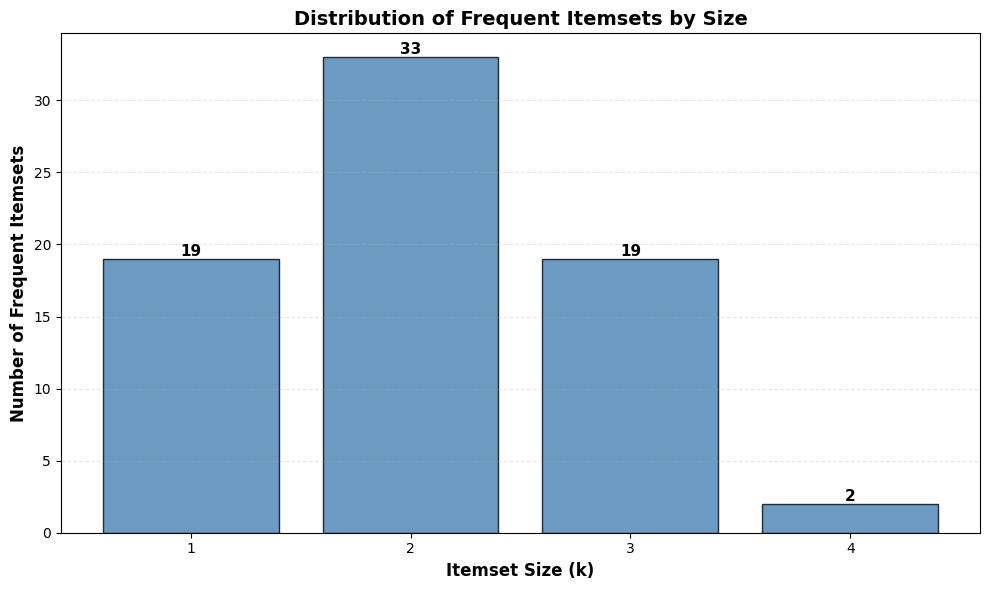

✓ Saved to: itemset_distribution.png
Diminishing returns: 19 → 2 itemsets from size 1 to 4


In [ ]:
# ITEMSET SIZE DISTRIBUTION
itemset_counts = {k: len(v) for k, v in miner.frequent_itemsets.items()}

plt.figure(figsize=(10, 6))

sizes = list(itemset_counts.keys())
counts = list(itemset_counts.values())

bars = plt.bar(sizes, counts, color="steelblue", alpha=0.8, edgecolor="black")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

plt.xlabel("Itemset Size (k)", fontsize=12, fontweight="bold")
plt.ylabel("Number of Frequent Itemsets", fontsize=12, fontweight="bold")
plt.title("Distribution of Frequent Itemsets by Size", fontsize=14, fontweight="bold")
plt.xticks(sizes)
plt.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
# plt.savefig('itemset_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved to: itemset_distribution.png")
print(
    f"Diminishing returns: {counts[0]} → {counts[-1]} itemsets from size 1 to {max(sizes)}"
)

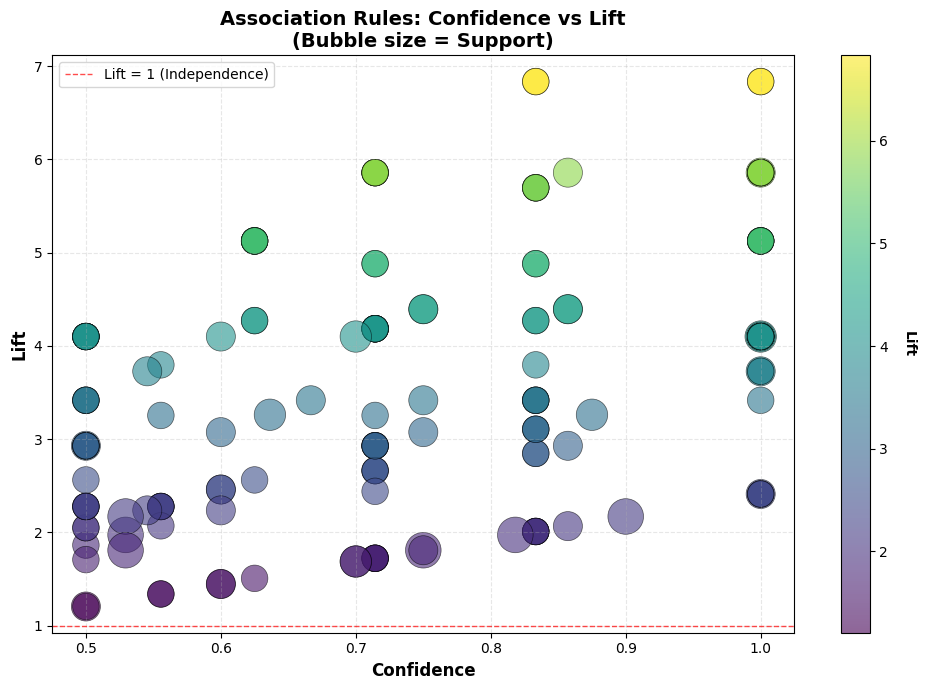

✓ Saved to: lift_confidence_scatter.png

Quadrant Analysis:
  High Confidence (>0.7) AND High Lift (>1.5): 100 rules
  → These represent the most reliable AND surprising associations.


In [ ]:
# LIFT VS CONFIDENCE SCATTER
min_support_plot = 0.05

# Filter rules
rules_plot = [r for r in miner.association_rules if r["support"] >= min_support_plot]

confidences = [r["confidence"] for r in rules_plot]
lifts = [r["lift"] for r in rules_plot]
supports = [r["support"] for r in rules_plot]

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    confidences,
    lifts,
    s=[s * 3000 for s in supports],
    c=lifts,
    cmap="viridis",
    alpha=0.6,
    edgecolors="black",
    linewidth=0.5,
)

plt.axhline(
    y=1.0,
    color="red",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="Lift = 1 (Independence)",
)

plt.xlabel("Confidence", fontsize=12, fontweight="bold")
plt.ylabel("Lift", fontsize=12, fontweight="bold")
plt.title(
    "Association Rules: Confidence vs Lift\n(Bubble size = Support)",
    fontsize=14,
    fontweight="bold",
)

cbar = plt.colorbar(scatter)
cbar.set_label("Lift", rotation=270, labelpad=20, fontweight="bold")

plt.legend(loc="upper left")
plt.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
# plt.savefig('lift_confidence_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Quadrant analysis
high_conf_high_lift = len(
    [r for r in rules_plot if r["confidence"] > 0.7 and r["lift"] > 1.5]
)
print("✓ Saved to: lift_confidence_scatter.png")
print("\nQuadrant Analysis:")
print(f"  High Confidence (>0.7) AND High Lift (>1.5): {high_conf_high_lift} rules")
print("  → These represent the most reliable AND surprising associations.")